In [3]:
import itertools
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

## 1. Generate simulated transaction datasets

In [4]:
def generate_transactions(N, d, w, seed=42):
    """
    N = number of transactions
    d = number of unique items in the whole dataset
    w = transaction width (items per transaction)
    """

    # wrong
    if w > d:
        raise ValueError("w cannot be larger than d.")
    if N * w < d:
        raise ValueError(
            "N * w must be at least d so that every item can appear."
        )

    rng = random.Random(seed)

    items = [f"I{i}" for i in range(d)]
    transactions = []

    shuffled_items = items.copy()
    rng.shuffle(shuffled_items)

    index = 0

    while index < d:
        transaction = shuffled_items[index:index + w]

        if len(transaction) < w:
            available = [
                item for item in items
                if item not in transaction
            ]

            transaction += rng.sample(available,w - len(transaction))

        transactions.append(transaction)
        index += w

    while len(transactions) < N:
        transaction = rng.sample(items, w)
        transactions.append(transaction)

    rng.shuffle(transactions)

    return transactions

## 2. Apriori

In [5]:
# convert transactions for mlxtend Apriori
def encode_transactions(transactions):

    encoder = TransactionEncoder()
    encoded = encoder.fit(transactions).transform(transactions)
    df = pd.DataFrame(encoded, columns=encoder.columns_)

    return df

def run_apriori(transactions, min_support=0.10, min_confidence=0.50):

    df = encode_transactions(transactions)

    start = time.perf_counter() # start time

    frequent_itemsets = apriori(
        df,
        min_support=min_support,
        use_colnames=True
    )

    if len(frequent_itemsets) > 0:
        rules = association_rules(
            frequent_itemsets,
            metric="confidence",
            min_threshold=min_confidence
        )
    else:
        rules = pd.DataFrame()

    end = time.perf_counter() # end time

    runtime = end - start

    return runtime, frequent_itemsets, rules

## 3. Brute-force approach

In [6]:
def theoretical_rule_count(d):
    return 3**d - 2**(d + 1) + 1

def run_bruteforce(transactions, d, min_support=0.10, min_confidence=0.50):

    items = [f"I{i}" for i in range(d)]

    transaction_sets = [set(t) for t in transactions]
    N = len(transaction_sets)
    valid_rule_count = 0
    interesting_rule_count = 0

    start = time.perf_counter() # start time

    for states in itertools.product([0, 1, 2], repeat=d):

        antecedent = {
            items[i]
            for i, state in enumerate(states)
            if state == 1
        }

        consequent = {
            items[i]
            for i, state in enumerate(states)
            if state == 2
        }

        if not antecedent or not consequent:
            continue

        valid_rule_count += 1

        antecedent_count = 0
        union_count = 0

        XY = antecedent | consequent

        for transaction in transaction_sets:
            if antecedent.issubset(transaction):
                antecedent_count += 1
                if XY.issubset(transaction):
                    union_count += 1
        support = union_count / N

        if antecedent_count > 0:
            confidence = union_count / antecedent_count
        else:
            confidence = 0

        if (support >= min_support and confidence >= min_confidence):
            interesting_rule_count += 1

    end = time.perf_counter() # end time

    runtime = end - start

    return runtime, valid_rule_count, interesting_rule_count

## 4. Variable 1: d

In [7]:
N_FIXED = 500
W_FIXED = 5

MIN_SUPPORT = 0.10
MIN_CONFIDENCE = 0.50

d_values = list(range(5, 15))


# Apriori can be tested over the full range
apriori_times_d = []

# Brute-force may stop early
bf_d_values = []
bf_times_d = []
# stop after a completed run exceeds this threshold
MAX_BRUTEFORCE_SECONDS = 30

for d in d_values:
    print(f"\nd = {d}")
    transactions = generate_transactions(
        N=N_FIXED,
        d=d,
        w=W_FIXED,
        seed=42
    )

    # Apriori
    apriori_time, itemsets, rules = run_apriori(
        transactions,
        min_support=MIN_SUPPORT,
        min_confidence=MIN_CONFIDENCE
    )
    apriori_times_d.append(apriori_time)
    print(f"Apriori: {apriori_time:.6f} s")

    # Brute force
    # stop brute-force when exceeding threshold
    if (
        len(bf_times_d) > 0
        and bf_times_d[-1] > MAX_BRUTEFORCE_SECONDS
    ):
        print("Brute-force skipped.")
        continue

    bf_time, rule_count, interesting = run_bruteforce(
        transactions,
        d=d,
        min_support=MIN_SUPPORT,
        min_confidence=MIN_CONFIDENCE
    )

    bf_d_values.append(d)
    bf_times_d.append(bf_time)
    print(f"Brute-force: {bf_time:.6f} s")
    print(f"Rules checked: {rule_count}")


d = 5
Apriori: 0.011456 s
Brute-force: 0.020992 s
Rules checked: 180

d = 6
Apriori: 0.008354 s
Brute-force: 0.052643 s
Rules checked: 602

d = 7
Apriori: 0.008410 s


c:\Users\24242\.conda\envs\datamining\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:184: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


Brute-force: 0.156394 s
Rules checked: 1932

d = 8
Apriori: 0.010784 s
Brute-force: 0.401964 s
Rules checked: 6050

d = 9
Apriori: 0.009562 s
Brute-force: 1.141210 s
Rules checked: 18660

d = 10
Apriori: 0.007600 s
Brute-force: 2.983064 s
Rules checked: 57002

d = 11
Apriori: 0.004785 s
Brute-force: 8.307660 s
Rules checked: 173052

d = 12
Apriori: 0.005165 s
Brute-force: 23.450183 s
Rules checked: 523250

d = 13
Apriori: 0.005609 s
Brute-force: 65.869417 s
Rules checked: 1577940

d = 14
Apriori: 0.004819 s
Brute-force skipped.


## Plot

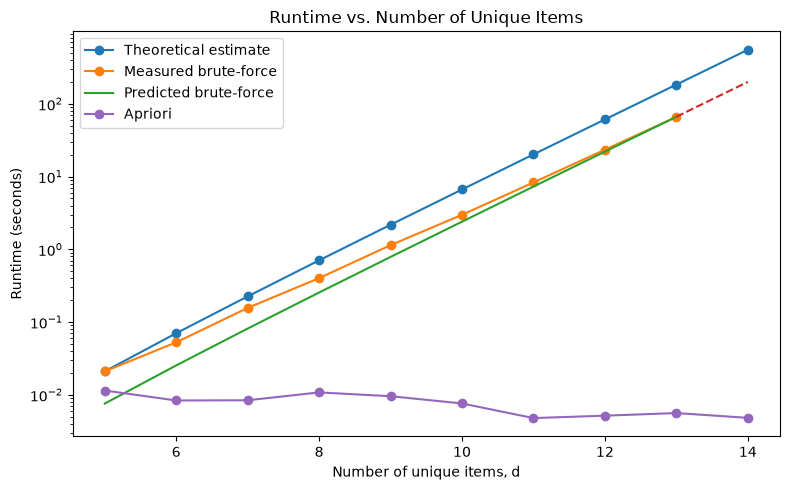

In [8]:
# Theoretical estimate
def theoretical_rule_count(d):
    return 3**d - 2**(d + 1) + 1

d_calibration = bf_d_values[0]
t_calibration_d = bf_times_d[0]

C_d = (
    t_calibration_d
    / theoretical_rule_count(d_calibration)
)
theoretical_times_d = np.array([
    C_d * theoretical_rule_count(d)
    for d in d_values
])

# Predicted brute-force
X_d = np.array([
    theoretical_rule_count(d)
    for d in bf_d_values
], dtype=float)

y_d = np.array(
    bf_times_d,
    dtype=float
)

a_d = np.dot(X_d, y_d) / np.dot(X_d, X_d)

predicted_times_d = np.array([
    a_d * theoretical_rule_count(d)
    for d in d_values
])


# Plot
d_array = np.array(d_values)
last_measured_d = max(bf_d_values)

plt.figure(figsize=(8, 5))

plt.plot(
    d_values,
    theoretical_times_d,
    marker="o",
    label="Theoretical estimate"
)

plt.plot(
    bf_d_values,
    bf_times_d,
    marker="o",
    label="Measured brute-force"
)

fitted_mask = d_array <= last_measured_d

plt.plot(
    d_array[fitted_mask],
    predicted_times_d[fitted_mask],
    label="Predicted brute-force"
)

extrapolated_mask = d_array >= last_measured_d

plt.plot(
    d_array[extrapolated_mask],
    predicted_times_d[extrapolated_mask],
    linestyle="--",
)

plt.plot(
    d_values,
    apriori_times_d,
    marker="o",
    label="Apriori"
)

plt.xlabel("Number of unique items, d")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime vs. Number of Unique Items")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

## 5. Variable 2: N

In [9]:
D_FIXED = 8
W_FIXED = 5

MIN_SUPPORT = 0.10
MIN_CONFIDENCE = 0.50

N_values = [100, 250, 500, 1000, 2000, 4000, 8000]


# Apriori can be tested over the full range
apriori_times_N = []

# Brute-force may stop early
bf_N_values = []
bf_times_N = []
# stop after a completed run exceeds this threshold
MAX_BRUTEFORCE_SECONDS = 30


for N in N_values:
    print(f"\nN = {N}")

    transactions = generate_transactions(
        N=N,
        d=D_FIXED,
        w=W_FIXED,
        seed=42
    )

    # Apriori
    apriori_time, itemsets, rules = run_apriori(
        transactions,
        min_support=MIN_SUPPORT,
        min_confidence=MIN_CONFIDENCE
    )

    apriori_times_N.append(apriori_time)

    print(f"Apriori: {apriori_time:.6f} s")

    # Brute force
    # stop brute-force when exceeding threshold
    if (
        len(bf_times_N) > 0
        and bf_times_N[-1] > MAX_BRUTEFORCE_SECONDS
    ):
        print("Brute-force skipped.")
        continue

    bf_time, rule_count, interesting = run_bruteforce(
        transactions,
        d=D_FIXED,
        min_support=MIN_SUPPORT,
        min_confidence=MIN_CONFIDENCE
    )

    bf_N_values.append(N)
    bf_times_N.append(bf_time)

    print(f"Brute-force: {bf_time:.6f} s")
    print(f"Rules checked: {rule_count}")


N = 100
Apriori: 0.014917 s
Brute-force: 0.096059 s
Rules checked: 6050

N = 250
Apriori: 0.009028 s
Brute-force: 0.205487 s
Rules checked: 6050

N = 500
Apriori: 0.008899 s
Brute-force: 0.400598 s
Rules checked: 6050

N = 1000
Apriori: 0.009489 s
Brute-force: 0.797619 s
Rules checked: 6050

N = 2000
Apriori: 0.009700 s
Brute-force: 1.576552 s
Rules checked: 6050

N = 4000
Apriori: 0.009544 s
Brute-force: 3.159492 s
Rules checked: 6050

N = 8000
Apriori: 0.012468 s
Brute-force: 6.312885 s
Rules checked: 6050


## Plot

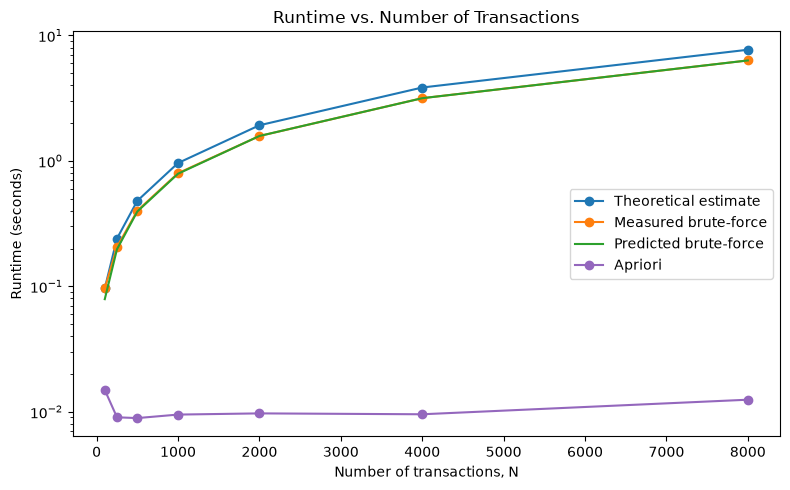

In [10]:
# Theoretical estimate
N_calibration = bf_N_values[0]
t_calibration_N = bf_times_N[0]

C_N = (
    t_calibration_N
    / N_calibration
)

theoretical_times_N = np.array([
    C_N * N
    for N in N_values
])


# Predicted brute-force
X_N = np.array(
    bf_N_values,
    dtype=float
)

y_N = np.array(
    bf_times_N,
    dtype=float
)

a_N = np.dot(X_N, y_N) / np.dot(X_N, X_N)

predicted_times_N = np.array([
    a_N * N
    for N in N_values
])


# Plot
N_array = np.array(N_values)
last_measured_N = max(bf_N_values)

plt.figure(figsize=(8, 5))

plt.plot(
    N_values,
    theoretical_times_N,
    marker="o",
    label="Theoretical estimate"
)

plt.plot(
    bf_N_values,
    bf_times_N,
    marker="o",
    label="Measured brute-force"
)

fitted_mask = N_array <= last_measured_N

plt.plot(
    N_array[fitted_mask],
    predicted_times_N[fitted_mask],
    label="Predicted brute-force"
)

extrapolated_mask = N_array >= last_measured_N

plt.plot(
    N_array[extrapolated_mask],
    predicted_times_N[extrapolated_mask],
    linestyle="--"
)

plt.plot(
    N_values,
    apriori_times_N,
    marker="o",
    label="Apriori"
)

plt.xlabel("Number of transactions, N")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime vs. Number of Transactions")

plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()